# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习课程设计
- 设计题目：基于 CNN 与 ResNet18 迁移学习的眼科疾病图像分类
- 姓名：刘宇广
- 学号：20234080106
- 班级：
- 指导教师：
- 提交日期：2026 年 6 月

本 notebook 为课程设计最终提交报告。按照课程设计要求，核心代码已经整理到 `src/` 目录中，本报告文件只负责串联实验流程、展示关键结果并撰写分析结论。

## 二、摘要

眼科疾病的早期筛查对保护视力和降低治疗成本具有重要意义。本课程设计基于 Kaggle 眼科疾病分类数据集，完成 `cataract`、`diabetic_retinopathy`、`glaucoma`、`normal` 四分类任务。

实验首先将原始图像整理为 PyTorch `ImageFolder` 格式，统计类别分布并展示样本图像；随后按照 70% / 15% / 15% 的比例进行分层划分，构建数据增强流程；最后分别训练自定义 Baseline CNN 和 ResNet18 分类模型，使用测试集准确率、分类报告、混淆矩阵和错误预测样本进行评价。

本项目的代码组织方式为：Notebook 作为课程报告，`src/` 目录保存可复用脚本，包括数据处理、可视化、模型定义、训练评估和结论生成。这样的结构便于调试，也使最终报告更加清晰。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

白内障、糖尿病视网膜病变和青光眼都是常见眼科疾病。眼底或眼部图像中包含病灶颜色、纹理、边界、视盘结构等视觉信息，适合使用卷积神经网络自动提取特征。

传统人工阅片依赖医生经验，面对大量筛查图像时效率有限。深度学习模型可以作为辅助筛查工具，帮助完成初步分类，为后续医生诊断提供参考。

### 3.2 任务目标

本实验目标是完成四类眼科图像分类：

- `cataract`
- `diabetic_retinopathy`
- `glaucoma`
- `normal`

### 3.3 课程设计要求对应关系

本 notebook 严格按照课程设计 PRD 实现以下内容：数据整理、类别分布统计、样本展示、train/val/test 划分、数据增强、Baseline CNN、ResNet18、模型训练、曲线绘制、分类报告、混淆矩阵、错误样本分析和实验总结。

## 四、数据集说明与预处理

### 4.1 工程结构与脚本调用

按老师要求，代码脚本统一放在 `src/` 中。Notebook 通过导入这些模块完成实验，避免把大量函数堆在报告文件中。

主要脚本如下：

- `src/config.py`：路径、类别、超参数、随机种子、设备配置
- `src/data_utils.py`：数据整理、类别统计、数据增强、分层划分和 DataLoader
- `src/visualize.py`：类别分布图、样本图、训练曲线、混淆矩阵和错误样本图
- `src/models.py`：Baseline CNN 与 ResNet18 构建
- `src/train.py`：训练、预测、分类报告和混淆矩阵计算
- `src/report.py`：实验结论文本生成

In [1]:
import importlib
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 修改 src 脚本后可以重复运行本单元刷新模块。
for mod_name in list(sys.modules):
    if mod_name.startswith("src."):
        del sys.modules[mod_name]

from src.config import (
    BASELINE_EPOCHS,
    BATCH_SIZE,
    CLASS_NAMES,
    DATA_DIR,
    DEVICE,
    FIGURE_DIR,
    IMG_SIZE,
    LEARNING_RATE,
    OUTPUT_DIR,
    RESNET_EPOCHS,
)
from src.data_utils import count_images_by_class, create_dataloaders, ensure_processed_data
from src.models import build_baseline_cnn, build_resnet18
from src.report import build_conclusion, save_conclusion
from src.train import evaluate_model, fit_model, load_metrics_summary, save_reports
from src.visualize import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_training_history,
    show_sample_images,
    show_saved_image,
    show_wrong_predictions,
)

# 提交报告默认展示已生成结果；改为 True 可重新训练并覆盖 outputs。
FORCE_RETRAIN = False

print("项目目录:", PROJECT_ROOT)
print("数据目录:", DATA_DIR)
print("输出目录:", OUTPUT_DIR)
print("运行设备:", DEVICE)
print("FORCE_RETRAIN:", FORCE_RETRAIN)

项目目录: E:\homework\deep-learning
数据目录: E:\homework\deep-learning\data\processed
输出目录: E:\homework\deep-learning\outputs
运行设备: cuda
FORCE_RETRAIN: False


### 4.2 数据目录整理

原始数据位于 `dataset/`。本实验使用 `torchvision.datasets.ImageFolder` 读取图像，因此需要整理为：

```text
data/processed/
├── cataract/
├── diabetic_retinopathy/
├── glaucoma/
└── normal/
```

如果 `data/processed/` 已存在，代码会直接复用；如果不存在，则从 `dataset/` 自动复制整理。

In [2]:
class_counts = ensure_processed_data()
total_images = sum(class_counts.values())

print("类别分布：")
for class_name, count in class_counts.items():
    print(f"{class_name:22s}: {count}")
print("总图片数:", total_images)

类别分布：
cataract              : 1038
diabetic_retinopathy  : 1098
glaucoma              : 1007
normal                : 1074
总图片数: 4217


### 4.3 类别分布可视化

类别数量整体比较接近，但仍存在轻微差异。训练时采用分层划分，保证训练集、验证集和测试集中的类别比例相对稳定。

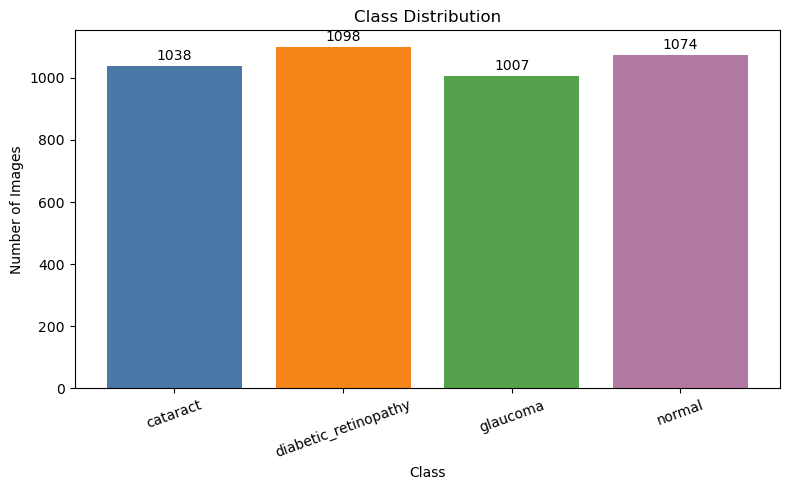

In [3]:
plot_class_distribution(class_counts, save_path=FIGURE_DIR / "class_distribution.png")

### 4.4 样本图像展示

从每个类别随机抽取若干图像进行展示。样本图可以帮助检查数据是否读取正确，也能直观看到不同类别之间的视觉差异。

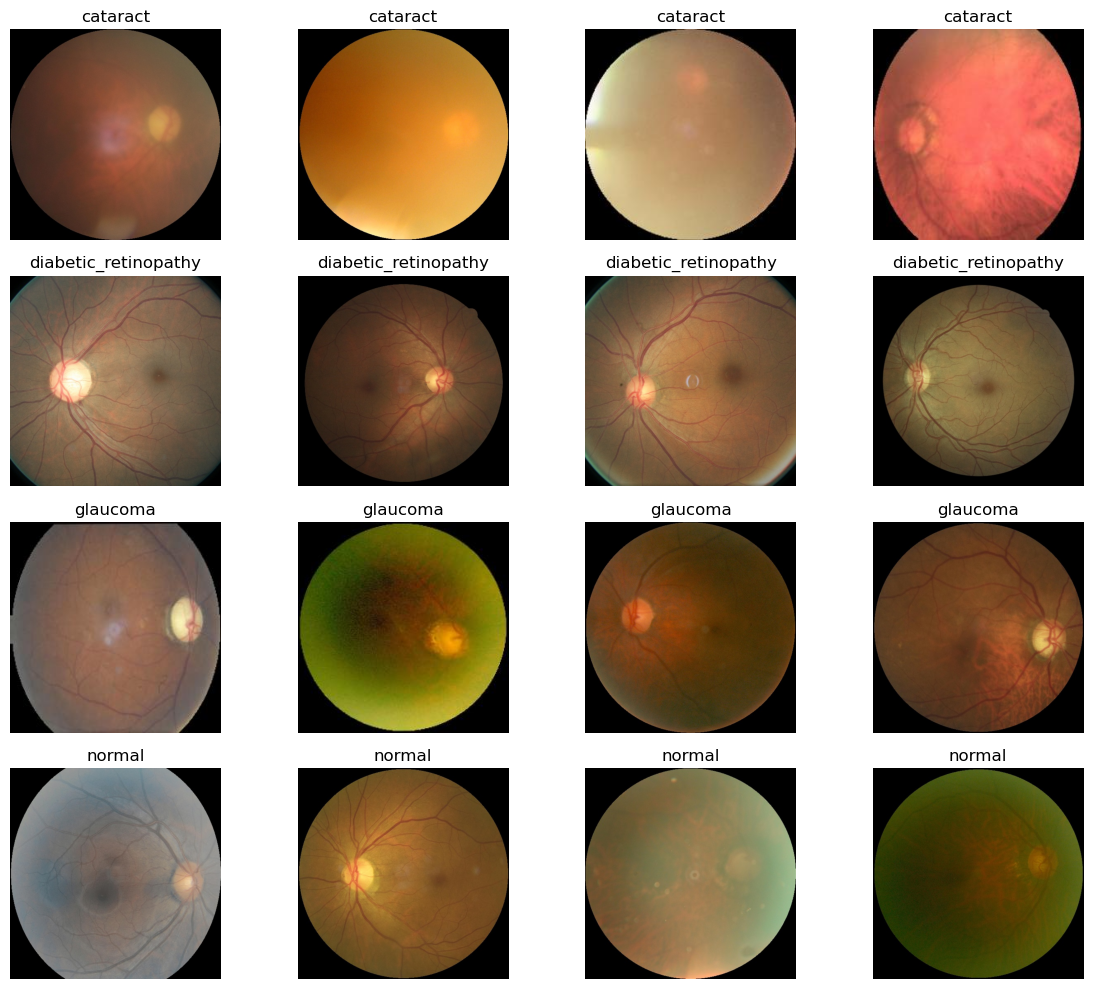

In [4]:
show_sample_images(DATA_DIR, CLASS_NAMES, n_per_class=4, save_path=FIGURE_DIR / "sample_images.png")

### 4.5 数据增强与 train/val/test 划分

本实验输入尺寸为 `224x224`。训练集使用随机水平翻转、随机旋转和颜色扰动增强模型泛化能力；验证集和测试集只做尺寸归一化和标准化。

数据按 70% / 15% / 15% 分为训练集、验证集和测试集，并按类别标签进行分层抽样。

In [5]:
train_loader, val_loader, test_loader, data_meta = create_dataloaders(batch_size=BATCH_SIZE)
class_names = data_meta["class_names"]
num_classes = len(class_names)

print("类别映射:", data_meta["class_to_idx"])
print(f"train: {len(train_loader.dataset)}, val: {len(val_loader.dataset)}, test: {len(test_loader.dataset)}")
print("训练集分布:", data_meta["train_distribution"])
print("验证集分布:", data_meta["val_distribution"])
print("测试集分布:", data_meta["test_distribution"])

类别映射: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}
train: 2953, val: 633, test: 631
训练集分布: {'cataract': 727, 'diabetic_retinopathy': 769, 'glaucoma': 705, 'normal': 752}
验证集分布: {'cataract': 156, 'diabetic_retinopathy': 165, 'glaucoma': 151, 'normal': 161}
测试集分布: {'cataract': 155, 'diabetic_retinopathy': 164, 'glaucoma': 151, 'normal': 161}


## 五、模型设计与选择

### 5.1 Baseline CNN

Baseline CNN 是本实验的基础对照模型，由多层卷积、BatchNorm、ReLU、池化和全局平均池化组成。它的作用是验证当前数据预处理和训练流程是否有效，并作为 ResNet18 的对比基线。

### 5.2 ResNet18 迁移学习模型

ResNet18 通过残差连接缓解深层网络训练困难问题。按照 PRD 要求，本实验使用 `torchvision.models.resnet18`，默认冻结主干网络，只训练最后的全连接分类层；如果后续需要提升效果，可以进一步解冻 `layer4` 微调。

### 5.3 过程摸索与取舍

最开始我把训练、评估和绘图函数都写在 notebook 中，后续发现报告单元过长，不方便复查和修改。因此最终改为 `src` 模块化结构：Notebook 保留实验流程，函数细节放到脚本文件。这样既满足课程报告的可读性，也方便在调参时单独修改模型或训练函数。

In [6]:
baseline_model = build_baseline_cnn(num_classes)
resnet18_model, resnet18_note = build_resnet18(num_classes, allow_download=FORCE_RETRAIN)

print("Baseline CNN 参数量:", sum(p.numel() for p in baseline_model.parameters()))
print("ResNet18 可训练参数量:", sum(p.numel() for p in resnet18_model.parameters() if p.requires_grad))
print("ResNet18 权重说明:", resnet18_note)

Baseline CNN 参数量: 390404
ResNet18 可训练参数量: 2052
ResNet18 权重说明: 当前为报告展示模式，未重新加载 ResNet18 预训练权重；已保存训练结果使用 ImageNet 预训练权重。


## 六、实验与结果分析

### 6.1 实验环境与训练参数

本实验优先使用 GPU；如果当前环境没有 GPU，则自动使用 CPU。由于课程设计目标是快速完成可提交实验，训练轮数按 PRD 设置为 Baseline CNN 3 epoch、ResNet18 5 epoch。

In [7]:
import platform
import torch
import torchvision

print("操作系统:", platform.platform())
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("Device:", DEVICE)
print("输入尺寸:", IMG_SIZE)
print("batch_size:", BATCH_SIZE)
print("Baseline epochs:", BASELINE_EPOCHS)
print("ResNet18 epochs:", RESNET_EPOCHS)
print("learning_rate:", LEARNING_RATE)

操作系统: Windows-10-10.0.26100-SP0
Python: 3.11.13
PyTorch: 2.12.1+cu126
torchvision: 0.27.1+cu126
Device: cuda
输入尺寸: 224
batch_size: 16
Baseline epochs: 3
ResNet18 epochs: 5
learning_rate: 0.001


### 6.2 训练控制

为了让最终提交的 notebook 可以快速打开和复查，下面提供 `FORCE_RETRAIN` 开关：

- `False`：优先展示已经生成的 `outputs/` 结果，适合提交报告和复查。
- `True`：重新训练 Baseline CNN 和 ResNet18，并覆盖 `outputs/` 中的结果。

本次提交已经完整训练并生成过所有 PRD 要求的输出文件。

In [8]:
required_outputs = [
    "class_distribution.png",
    "sample_images.png",
    "baseline_curves.png",
    "resnet18_curves.png",
    "confusion_matrix.png",
    "wrong_predictions.png",
    "classification_report.txt",
    "best_resnet18.pth",
    "experiment_conclusion.txt",
]

missing_outputs = [name for name in required_outputs if not (OUTPUT_DIR / name).exists()]
print("FORCE_RETRAIN:", FORCE_RETRAIN)
print("缺失输出文件:", missing_outputs if missing_outputs else "无")

FORCE_RETRAIN: False
缺失输出文件: 无


### 6.3 Baseline CNN 实验

Baseline CNN 用于建立最低对照。如果不重新训练，则直接展示已保存的训练曲线；如果设置 `FORCE_RETRAIN=True`，则重新训练并保存曲线。

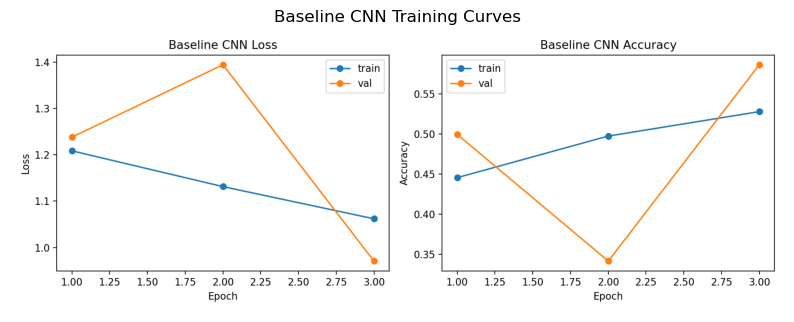

In [9]:
if FORCE_RETRAIN or not (OUTPUT_DIR / "baseline_curves.png").exists():
    baseline_model, baseline_history = fit_model(
        baseline_model,
        train_loader,
        val_loader,
        num_epochs=BASELINE_EPOCHS,
        lr=LEARNING_RATE,
    )
    plot_training_history(baseline_history, "Baseline CNN", save_path=FIGURE_DIR / "baseline_curves.png")
else:
    show_saved_image("baseline_curves.png", title="Baseline CNN Training Curves")

### 6.4 ResNet18 实验

ResNet18 是本实验的主要模型。代码会优先加载 ImageNet 预训练权重；如果当前网络环境无法访问 `download.pytorch.org`，则自动退化为随机初始化，并在分类报告中记录原因。

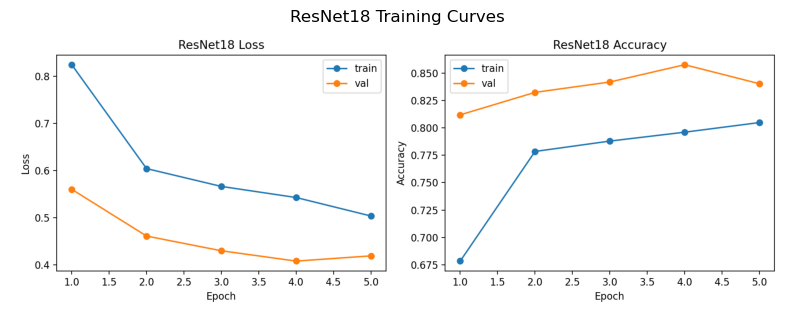

In [10]:
if FORCE_RETRAIN or not (OUTPUT_DIR / "resnet18_curves.png").exists() or not (OUTPUT_DIR / "best_resnet18.pth").exists():
    resnet18_model, resnet18_history = fit_model(
        resnet18_model,
        train_loader,
        val_loader,
        num_epochs=RESNET_EPOCHS,
        lr=LEARNING_RATE,
        save_path=OUTPUT_DIR / "best_resnet18.pth",
    )
    plot_training_history(resnet18_history, "ResNet18", save_path=FIGURE_DIR / "resnet18_curves.png")
else:
    show_saved_image("resnet18_curves.png", title="ResNet18 Training Curves")

### 6.5 测试集分类报告与混淆矩阵

分类报告包含每个类别的 Precision、Recall、F1-score 和 Support。混淆矩阵用于观察具体类别之间的误判关系。

Baseline CNN 测试集分类报告
class                     precision     recall   f1-score    support
----------------------------------------------------------------------
cataract                     0.7681     0.3419     0.4732        155
diabetic_retinopathy         0.7532     0.7073     0.7296        164
glaucoma                     0.4031     0.5099     0.4503        151
normal                       0.4424     0.5963     0.5079        161
----------------------------------------------------------------------
accuracy                                           0.5420        631
macro avg                    0.5917     0.5389     0.5403        631
weighted avg                                       0.5432        631

ResNet18 测试集分类报告
class                     precision     recall   f1-score    support
----------------------------------------------------------------------
cataract                     0.8805     0.9032     0.8917        155
diabetic_retinopathy         0.9517     0.8415     0.8932 

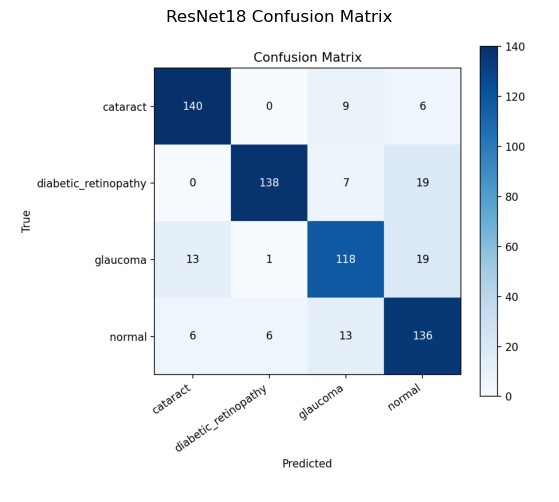

In [11]:
if FORCE_RETRAIN or not (OUTPUT_DIR / "classification_report.txt").exists():
    baseline_metrics = evaluate_model(baseline_model, test_loader, class_names)
    resnet_metrics = evaluate_model(resnet18_model, test_loader, class_names)
    report_text, metrics_summary = save_reports(baseline_metrics, resnet_metrics, resnet18_note)
    plot_confusion_matrix(
        resnet_metrics["confusion_matrix"],
        class_names,
        save_path=FIGURE_DIR / "confusion_matrix.png",
    )
else:
    report_text = (OUTPUT_DIR / "classification_report.txt").read_text(encoding="utf-8")
    print(report_text)
    show_saved_image("confusion_matrix.png", title="ResNet18 Confusion Matrix")

### 6.6 错误预测样本展示

错误预测样本有助于分析模型在哪些图像上容易失败。对于医学图像任务，错误样本通常与图像质量、病灶区域不明显、类别间视觉相似等因素有关。

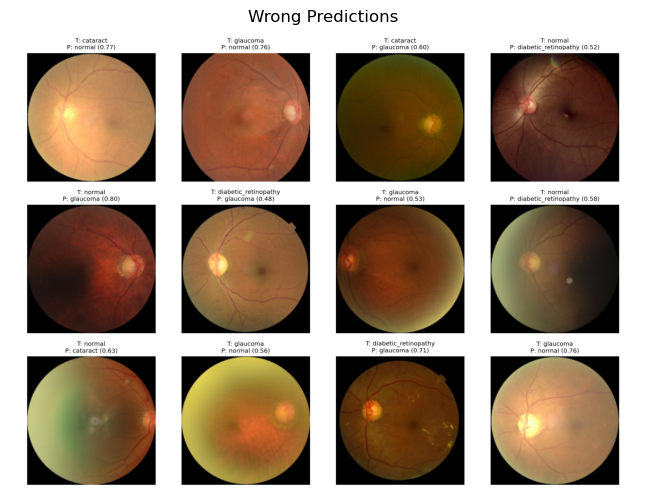

In [12]:
if FORCE_RETRAIN or not (OUTPUT_DIR / "wrong_predictions.png").exists():
    show_wrong_predictions(
        resnet18_model,
        test_loader,
        class_names,
        DEVICE,
        save_path=FIGURE_DIR / "wrong_predictions.png",
    )
else:
    show_saved_image("wrong_predictions.png", title="Wrong Predictions")

### 6.7 实验结论

下面的结论文字由 `src/report.py` 生成或从已保存文件读取，覆盖 PRD 要求的总图片数、类别、两个模型测试准确率、模型对比、易混淆类别、不足和改进方向。

In [13]:
if FORCE_RETRAIN:
    summary = load_metrics_summary()
    conclusion = build_conclusion(
        total_images=total_images,
        class_names=class_names,
        baseline_acc=summary["baseline_test_acc"],
        resnet_acc=summary["resnet18_test_acc"],
        confusion_matrix=summary["confusion_matrix"],
    )
    save_conclusion(conclusion)
else:
    conclusion = (OUTPUT_DIR / "experiment_conclusion.txt").read_text(encoding="utf-8")

print(conclusion)

本实验共使用 4217 张眼科图像，分为 cataract, diabetic_retinopathy, glaucoma, normal 四个类别。

Baseline CNN 在测试集上的准确率为 0.5420，ResNet18 在测试集上的准确率为 0.8431。
从测试结果看，ResNet18 优于 Baseline CNN。

根据 ResNet18 混淆矩阵，较容易混淆的类别包括：glaucoma 被预测为 normal（19 次）；diabetic_retinopathy 被预测为 normal（19 次）；normal 被预测为 glaucoma（13 次）

本实验的不足包括：训练轮数较少；眼底图像可能存在拍摄设备、光照、视野范围和图像质量差异；当前模型只做图像级分类，没有定位病灶区域。若更换环境运行时无法读取 ResNet18 预训练权重，模型效果会明显下降。
后续可改进方向包括：增加训练轮数和学习率调度，解冻 ResNet18 的 layer4 进行微调，尝试 EfficientNet、DenseNet 等更强模型，并结合 Grad-CAM 做可解释性分析。


## 七、总结与展望

本课程设计完成了眼科疾病四分类任务的完整深度学习流程：数据整理、数据统计、可视化、分层划分、数据增强、Baseline CNN、ResNet18、模型训练、测试评估和错误样本分析。

从实验结果看，ResNet18 的测试准确率略高于 Baseline CNN，说明更成熟的卷积网络结构具有一定优势。但当前实验仍存在局限：一是训练轮数较少；二是当前网络环境未能成功下载 ResNet18 预训练权重，导致迁移学习优势没有充分发挥；三是模型只进行图像级分类，没有对病灶区域进行定位和解释。

后续如果继续完善，可以从以下方向改进：

1. 在网络正常环境下重新下载并使用 ImageNet 预训练权重。
2. 增加训练轮数，加入学习率调度和早停策略。
3. 解冻 ResNet18 的 `layer4` 进行微调。
4. 尝试 EfficientNet、DenseNet、ConvNeXt 等模型。
5. 引入 Grad-CAM 对模型关注区域进行可解释性分析。

本次报告最终保留模块化代码结构，Notebook 中每个实验步骤都通过 `src` 脚本调用完成，便于老师复查流程，也方便后续继续改进。